In [1]:
import numpy as np
np.random.randn(4,4)

array([[ 0.65385284, -0.03976108,  1.28232905, -0.12994562],
       [-0.20482912, -1.41480145,  0.13019574, -0.9191304 ],
       [ 0.5472911 , -0.18920571, -0.21535267, -0.33615928],
       [-2.72619181,  0.32550844,  0.8369553 ,  0.26054986]])

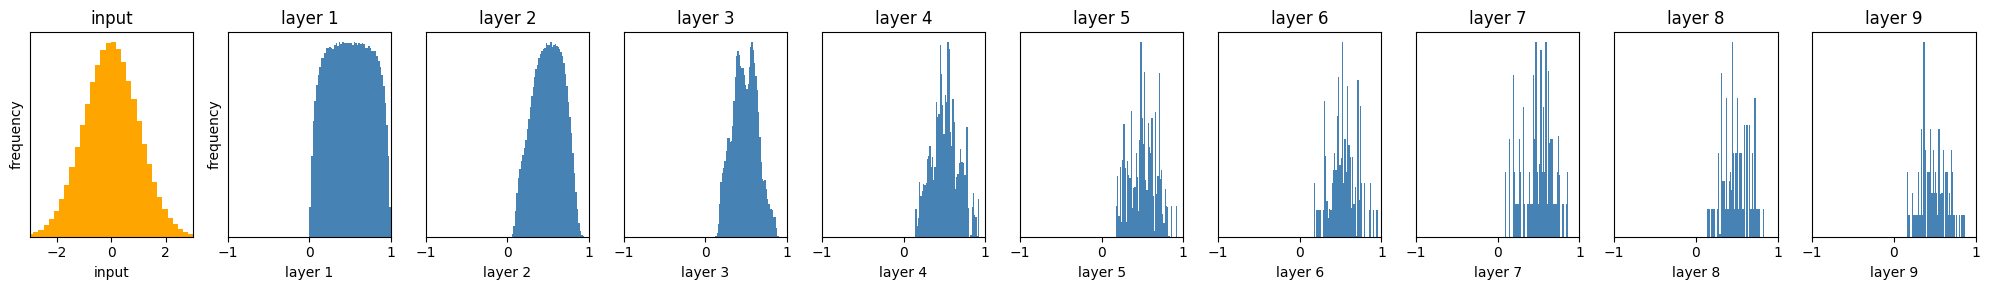

In [3]:
import numpy as np  # 导入numpy用于数值计算
import matplotlib.pyplot as plt  # 导入matplotlib用于绘图

# 模拟深度神经网络的前向传播
def simulate_forward_pass(n_layers=9, n_samples=10000, activation='tanh'):
    layer_outputs = []
    x_init = np.random.randn(n_samples, 100)  # 输入数据，标准正态分布
    x = x_init.copy()
    for i in range(n_layers):
        # 权重初始化（可调整）
        # W = np.random.randn(x.shape[1], 100) * 0.1  # 权重初始化
        W = np.random.randn(x.shape[1], 100) * np.sqrt(2.0/x.shape[1])  # He初始化（可切换）
        x = np.dot(x, W)
        if activation == 'sigmoid':
            x = 1 / (1 + np.exp(-x))
        elif activation == 'tanh':
            x = np.tanh(x)
        elif activation == 'relu':
            x = np.maximum(0, x)
        layer_outputs.append(x.flatten())
    return x_init.flatten(), layer_outputs

# 运行模拟前向传播，得到每层输出以及初始输入
x_init_flat, layer_outputs = simulate_forward_pass(n_layers=9, activation='sigmoid')

fig, axes = plt.subplots(1, 10, figsize=(20, 3))  # 1行10列，第一列画原始输入分布
axes[0].hist(x_init_flat, bins=50, color='orange', edgecolor='none')
axes[0].set_xlim(-3, 3)
axes[0].set_xlabel('input')
axes[0].set_ylabel('frequency')
axes[0].set_yticks([])
axes[0].set_title('input')

for i, (ax, output) in enumerate(zip(axes[1:], layer_outputs)):
    ax.hist(output, bins=50, color='steelblue', edgecolor='none')
    ax.set_xlim(-1, 1)
    ax.set_xlabel(f'layer {i+1}')
    if i == 0:
        ax.set_ylabel('frequency')
    ax.set_yticks([])
    ax.set_title(f'layer {i+1}')

plt.tight_layout()
plt.show()

# 梯度消失：使用 Sigmoid/Tanh 激活函数且权重初始化不当时，激活值逐渐集中在 0 附近，导致梯度越来越小。